In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

TASK1

Scenario A — App Review Analysis

Bias type: Selection bias.
App store reviews are typically left by users with very strong positive or negative experiences, meaning the sample is not representative of the full user base. This skews the average rating upward or downward and ignores the silent majority who may be moderately satisfied or experiencing issues but not motivated to post. As a result, concluding that most users are happy—and cutting customer support—could overlook widespread but unreported problems.
Fix: Collect in-app feedback from a random sample of active users to capture a more representative view.

Scenario B — Startup Success Study

Bias type: Survivorship bias.
The study only includes startups that are still operating and successful, ignoring those that failed, which removes critical comparison cases. This makes it seem like pivoting is strongly associated with success, when in reality many failed startups may also have pivoted. The conclusion overstates the importance of pivoting because it lacks a proper control group of unsuccessful companies.
Fix: Include both successful and failed startups in the dataset to compare how common pivoting is across outcomes.

Scenario C — Health Survey

Bias type: Nonresponse bias (a form of selection bias)
Only 10% of recipients responded, and those who chose to participate are likely more health-conscious or engaged, leading to inflated estimates of exercise and health. This makes the population appear healthier than it actually is, distorting any conclusions drawn for the broader group. The voluntary nature of the survey amplifies this bias.
Fix: Increase response rates through follow-ups or incentives and/or weight responses to better reflect the full population’s demographics and behavior.

Scenario D — Salary Benchmarking

Bias type: Selection bias.
The dataset overrepresents tech workers in large cities and underrepresents workers in smaller or rural areas, making the averages unrepresentative for different labor markets. Using this data in a small-town context can lead to inflated salary benchmarks that don’t align with local economic conditions. This distorts hiring decisions and may create budget or competitiveness issues.
Fix: Segment salary data by geography and industry, and ensure the comparison group matches the company’s local labor market.

TASK2

=== Population Summary (Ground Truth) ===
Mean Age: 40.02
Mean Income: $60,675.27
Mean Satisfaction: 1.94

Region Proportions:
region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64


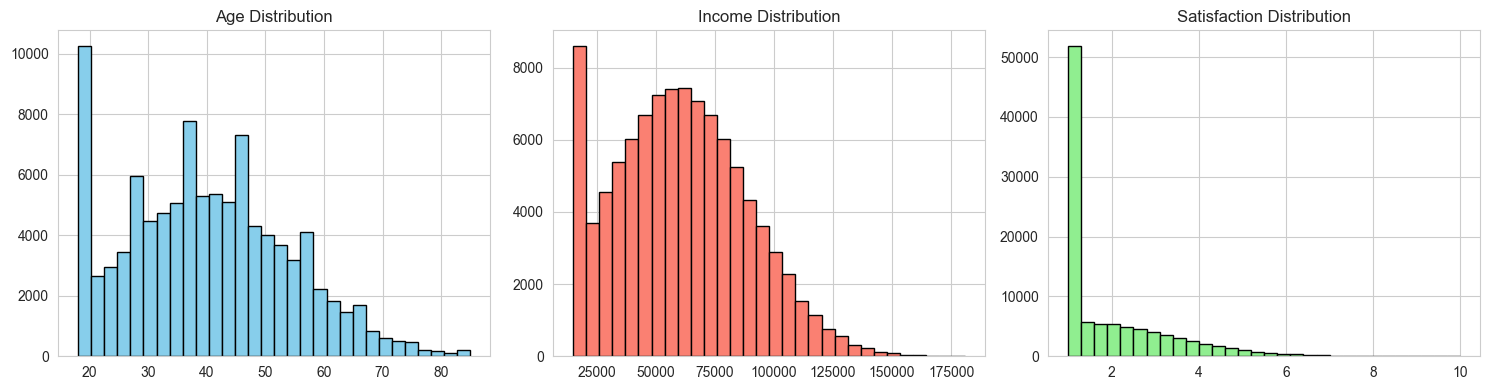

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100000

age = np.clip(np.random.normal(loc=40, scale=15, size=n), 18, 85).astype(int)

noise_income = np.random.normal(0, 20000, n)
income = 1500 * age + noise_income
income = np.clip(income, 15000, 250000)

noise_sat = np.random.normal(0, 2, n)
satisfaction = (income / 50000) + noise_sat
satisfaction = np.clip(satisfaction, 1, 10)

region = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    size=n,
    p=[0.6, 0.25, 0.15]
)

population = pd.DataFrame({
    "age": age,
    "income": income,
    "satisfaction": satisfaction,
    "region": region
})

mean_age = population["age"].mean()
mean_income = population["income"].mean()
mean_satisfaction = population["satisfaction"].mean()
region_proportions = population["region"].value_counts(normalize=True)

print("=== Population Summary (Ground Truth) ===")
print(f"Mean Age: {mean_age:.2f}")
print(f"Mean Income: ${mean_income:,.2f}")
print(f"Mean Satisfaction: {mean_satisfaction:.2f}")
print("\nRegion Proportions:")
print(region_proportions)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(population["age"], bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Age Distribution")

axes[1].hist(population["income"], bins=30, color="salmon", edgecolor="black")
axes[1].set_title("Income Distribution")

axes[2].hist(population["satisfaction"], bins=30, color="lightgreen", edgecolor="black")
axes[2].set_title("Satisfaction Distribution")

plt.tight_layout()
plt.show()

TASK3

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

true_mean_age = population["age"].mean()
true_mean_income = population["income"].mean()
true_mean_satisfaction = population["satisfaction"].mean()


def simple_random_sample(df, n=200):
    return df.sample(n=n)

def urban_sample(df, n=200):
    return df[df["region"] == "Urban"].sample(n=n)

def high_income_sample(df, n=200):
    median_income = df["income"].median()
    return df[df["income"] > median_income].sample(n=n)

#Draw one sample from each
srs = simple_random_sample(population)
urban = urban_sample(population)
high_income = high_income_sample(population)

# Compute means
def summarize(sample):
    return {
        "mean_age": sample["age"].mean(),
        "mean_income": sample["income"].mean(),
        "mean_satisfaction": sample["satisfaction"].mean()
    }

summary_table = pd.DataFrame([
    {"sample": "Population (True)", 
     "mean_age": true_mean_age, 
     "mean_income": true_mean_income, 
     "mean_satisfaction": true_mean_satisfaction},
    {"sample": "Simple Random", **summarize(srs)},
    {"sample": "Urban Only", **summarize(urban)},
    {"sample": "High Income", **summarize(high_income)},
])

print(summary_table)

              sample  mean_age   mean_income  mean_satisfaction
0  Population (True)  40.02052  60675.269282           1.936884
1      Simple Random  39.21500  58948.055838           1.942975
2         Urban Only  39.32000  62658.071396           2.044861
3        High Income  48.83500  83063.732248           2.331092


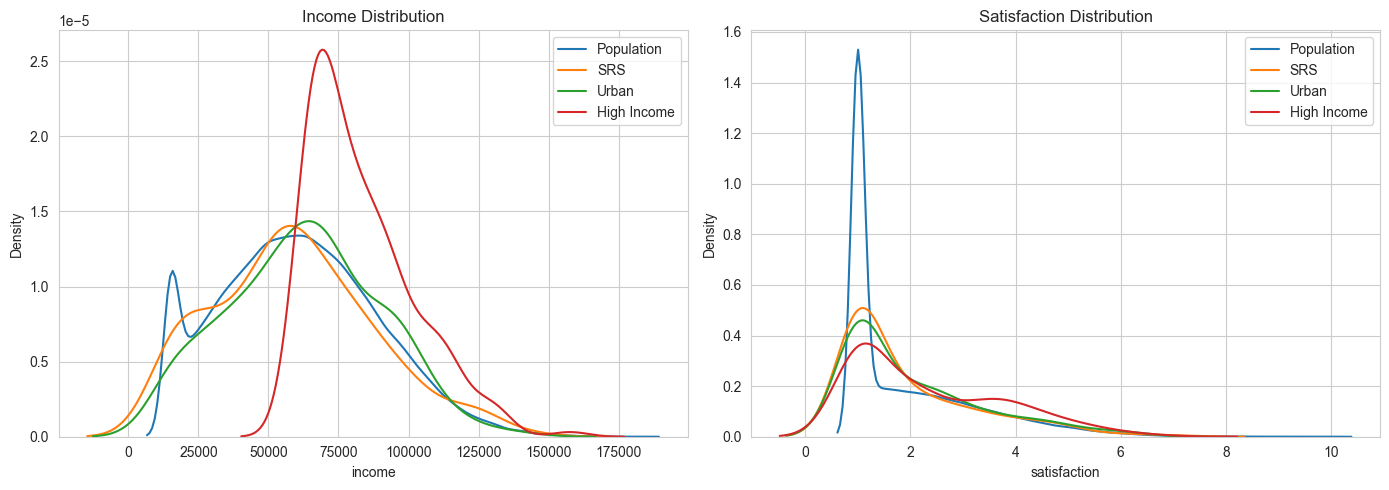

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income KDE
sns.kdeplot(population["income"], label="Population", ax=axes[0])
sns.kdeplot(srs["income"], label="SRS", ax=axes[0])
sns.kdeplot(urban["income"], label="Urban", ax=axes[0])
sns.kdeplot(high_income["income"], label="High Income", ax=axes[0])
axes[0].set_title("Income Distribution")

# Satisfaction KDE
sns.kdeplot(population["satisfaction"], label="Population", ax=axes[1])
sns.kdeplot(srs["satisfaction"], label="SRS", ax=axes[1])
sns.kdeplot(urban["satisfaction"], label="Urban", ax=axes[1])
sns.kdeplot(high_income["satisfaction"], label="High Income", ax=axes[1])
axes[1].set_title("Satisfaction Distribution")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
n_sim = 1000

means_srs = []
means_urban = []
means_high = []

for _ in range(n_sim):
    means_srs.append(simple_random_sample(population)["income"].mean())
    means_urban.append(urban_sample(population)["income"].mean())
    means_high.append(high_income_sample(population)["income"].mean())

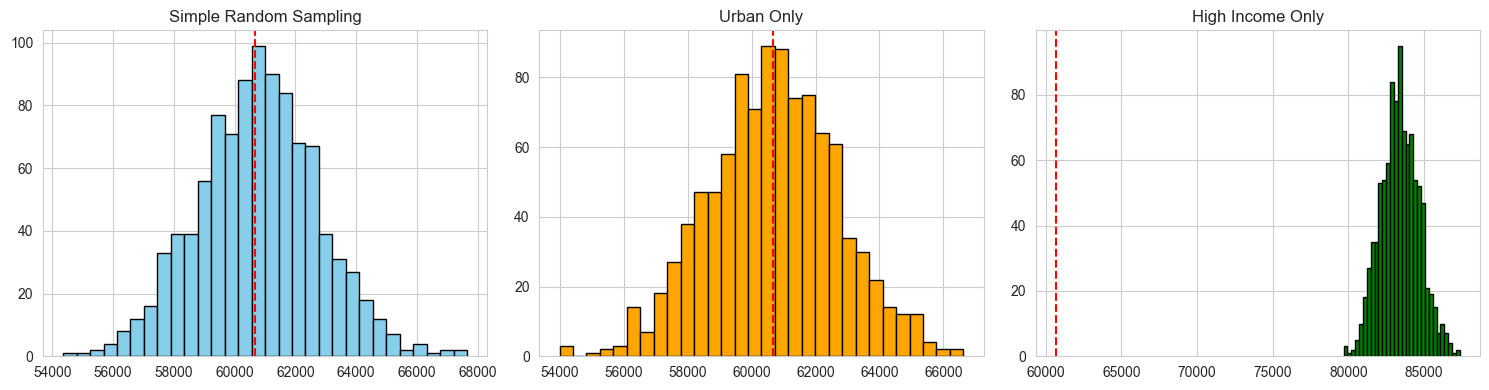

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# SRS
axes[0].hist(means_srs, bins=30, color="skyblue", edgecolor="black")
axes[0].axvline(true_mean_income, color="red", linestyle="--")
axes[0].set_title("Simple Random Sampling")

# Urban
axes[1].hist(means_urban, bins=30, color="orange", edgecolor="black")
axes[1].axvline(true_mean_income, color="red", linestyle="--")
axes[1].set_title("Urban Only")

# High Income
axes[2].hist(means_high, bins=30, color="green", edgecolor="black")
axes[2].axvline(true_mean_income, color="red", linestyle="--")
axes[2].set_title("High Income Only")

plt.tight_layout()
plt.show()

The Urban-only and High-income samples are biased; the simple random sample is not.

We can tell by where the sampling distributions are centered. The simple random sample is centered around the true population mean, while the biased samples are consistently shifted away from it (especially the high-income one, which is shifted upward). If the distribution isn’t centered on the true value, it’s biased.